   Student_ID  Sessions_Attended  Attendance_Percentage  Certified
0           1                 38                   95.0          1
1           2                 28                   70.0          0
2           3                 14                   35.0          0
3           4                  7                   17.5          0
4           5                 20                   50.0          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             980 non-null    int64  
 1   Sessions_Attended      980 non-null    int64  
 2   Attendance_Percentage  980 non-null    float64
 3   Certified              980 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 30.8 KB
None
Student_ID               0
Sessions_Attended        0
Attendance_Percentage    0
Certified                0
dtype: int64


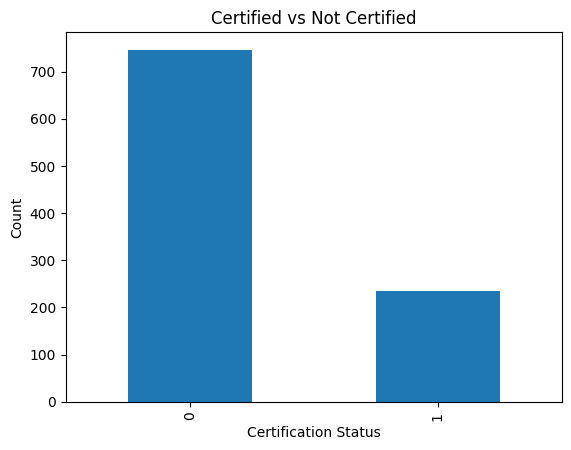

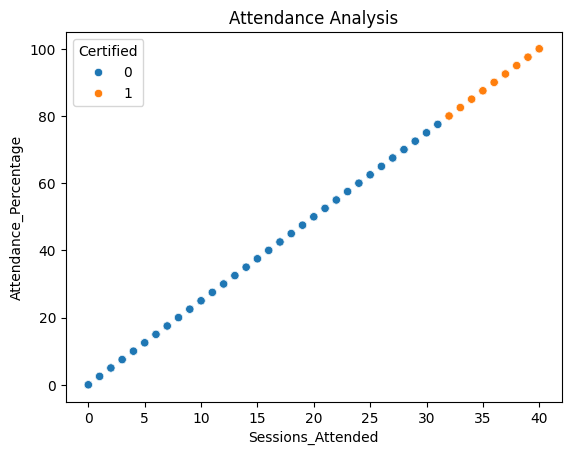

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score # Moved import statement here

np.random.seed(42)

students = 980

sessions_attended = np.random.randint(0, 41, students)

attendance_percentage = (sessions_attended / 40) * 100

certified = np.where(attendance_percentage >= 80, 1, 0)

df = pd.DataFrame({
    "Student_ID": range(1, students + 1),
    "Sessions_Attended": sessions_attended,
    "Attendance_Percentage": attendance_percentage,
    "Certified": certified
})

df.to_csv("attendance_data.csv", index=False)

print(df.head())
import pandas as pd

df = pd.read_csv("attendance_data.csv")

print(df.info())

print(df.isnull().sum())

df.drop_duplicates(inplace=True)
import matplotlib.pyplot as plt

df['Certified'].value_counts().plot(kind='bar')

plt.title("Certified vs Not Certified")
plt.xlabel("Certification Status")
plt.ylabel("Count")
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='Sessions_Attended',
    y='Attendance_Percentage',
    hue='Certified',
    data=df
)

plt.title("Attendance Analysis")
plt.show()
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['Sessions_Attended', 'Attendance_Percentage']]
y = df['Certified']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)
sessions = int(input("Enter sessions attended out of 40: "))

percentage = (sessions / 40) * 100

# Create a DataFrame for prediction with the correct column names
input_data = pd.DataFrame(
    [[sessions, percentage]],
    columns=['Sessions_Attended', 'Attendance_Percentage']
)

prediction = model.predict(input_data)

if prediction[0] == 1:
    print("Certified")
else:
    print("Not Certified")

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)